# 逐步看每一层的输入输出

顺序和数据流一致：edf → 切窗 → stem → 坐标编码 → 相加 → 掩码 → 注意力（RoPE、前缀掩码）→ 重建。每个 cell 只做一步，打印形状、画一张图。

In [1]:
import sys, math
sys.path.insert(0, '/Users/erqian/Desktop/util_udf/bci/eeg_fm_mini')
import numpy as np, torch, torch.nn.functional as F
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Hiragino Sans GB', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
torch.manual_seed(0)

from config import Cfg
from data import load_run
from model import EEGFM, ConvStem, FourierCoord, rope, prefix_mask, random_mask

cfg = Cfg()
print('P =', cfg.P, '点/秒   T =', cfg.T, '秒   d =', cfg.d_model, '   heads =', cfg.n_heads)

P = 160 点/秒   T = 8 秒   d = 128    heads = 4


## 1. 读一个 run：波形、坐标、事件

x      (64, 20000)   [导联, 采样点]，已按导联 z-score
coords (64, 3)  单位 dm，范围 -0.89 ~ 1.42
events (30, 3) {'T0': 1, 'T1': 2, 'T2': 3}   前 3 个： [[0, 0, 1], [672, 0, 3], [1328, 0, 1]]


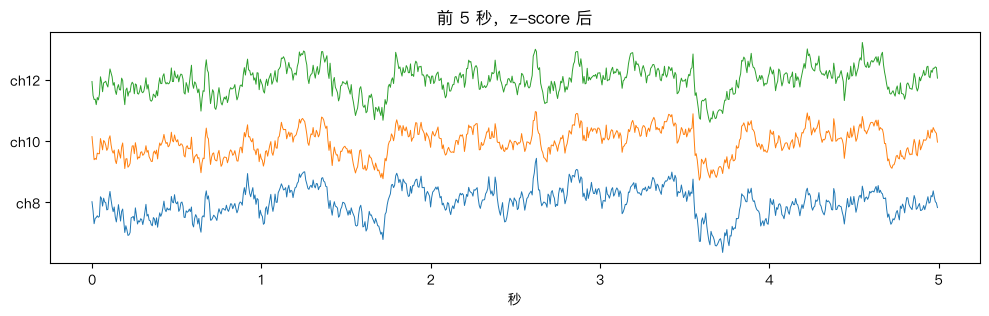

In [2]:
x, coords, events, ids = load_run(cfg, subj=1, run=4)
print('x     ', x.shape, '  [导联, 采样点]，已按导联 z-score')
print('coords', coords.shape, ' 单位 dm，范围', coords.min().round(2), '~', coords.max().round(2))
print('events', events.shape, ids, '  前 3 个：', events[:3].tolist())

fig, ax = plt.subplots(figsize=(12, 3))
t = np.arange(5 * cfg.fs) / cfg.fs
for i, ch in enumerate([8, 10, 12]):          # C3 / Cz / C4 附近
    ax.plot(t, x[ch, :5 * cfg.fs] + 4 * i, lw=.7)
ax.set(xlabel='秒', yticks=[0, 4, 8], yticklabels=['ch8', 'ch10', 'ch12'], title='前 5 秒，z-score 后')
plt.show()

## 2. 切成 [C, T, P]：每导联每秒一个 token

一个 8 秒窗 → (64, 8, 160)  共 512 个 token，每个 160 个采样点


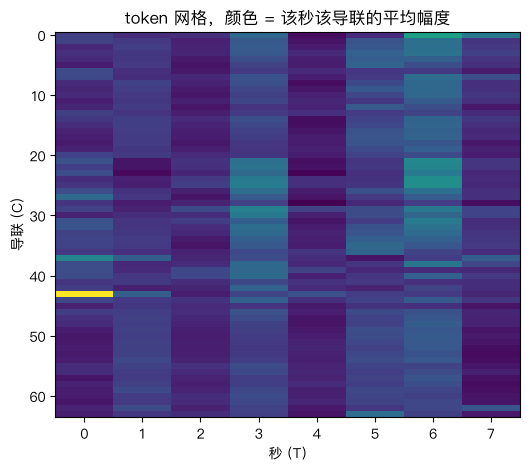

In [3]:
L = cfg.T * cfg.P
win = x[:, :L].reshape(x.shape[0], cfg.T, cfg.P)          # [C,T,P]
print('一个 8 秒窗 →', win.shape, ' 共', win.shape[0] * win.shape[1], '个 token，每个', win.shape[2], '个采样点')

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(np.abs(win).mean(-1), aspect='auto', cmap='viridis')
ax.set(xlabel='秒 (T)', ylabel='导联 (C)', title='token 网格，颜色 = 该秒该导联的平均幅度')
plt.show()

## 3. stem：160 个采样点 → 128 维向量，看每层的中间形状

In [4]:
stem = ConvStem(cfg.P, cfg.d_model)
tok = torch.from_numpy(win[10, 2])[None, None]             # 导联 10、第 2 秒 → [1, 1, 160]
h = tok
print('输入      ', tuple(h.shape), ' [batch, 通道, 长度]')
for layer in stem.net:
    h = layer(h)
    if isinstance(layer, torch.nn.Conv1d):
        print(f'{layer.__class__.__name__:<10}', tuple(h.shape), f'  核 {layer.kernel_size[0]} 点 = {layer.kernel_size[0]/cfg.fs*1000:.0f} ms, 步长 {layer.stride[0]}')
print('输出      ', tuple(h.squeeze(-1).shape), ' → 一个 token 的向量')

# 整窗一起过：[B,C,T,P] → [B,C,T,d]
hw = stem(torch.from_numpy(win)[None])
print('\n整窗', tuple(torch.from_numpy(win)[None].shape), '→', tuple(hw.shape))

输入       (1, 1, 160)  [batch, 通道, 长度]
Conv1d     (1, 32, 40)   核 16 点 = 100 ms, 步长 4
Conv1d     (1, 64, 10)   核 8 点 = 50 ms, 步长 4
Conv1d     (1, 128, 1)   核 10 点 = 62 ms, 步长 10
输出       (1, 128)  → 一个 token 的向量



整窗 (1, 64, 8, 160) → (1, 64, 8, 128)


## 4. 坐标 Fourier 编码：3 个数 → 36 维 sin/cos → 128 维

频率（每轴几把尺子） [  3.14   6.28  12.57  25.13  50.27 100.53]    n_freq = 6
坐标 (1, 64, 3) → sin/cos 特征 (1, 64, 36) → 线性 → (1, 64, 128)

导联 0 的坐标 [-0.789  0.514  0.63 ] 
它的 36 维特征前 6 个 [-0.615  0.97   0.471 -0.831 -0.924  0.707]


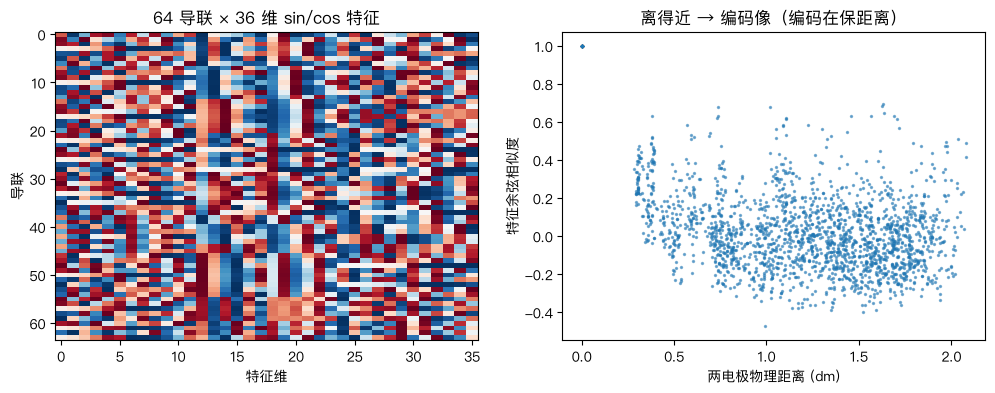

In [5]:
fc = FourierCoord(cfg.d_model, cfg.n_freq)
c = torch.from_numpy(coords)[None]                          # [1, C, 3]
ang = c.unsqueeze(-1) * fc.freqs                            # [1, C, 3, n_freq]
feat = torch.cat([ang.sin(), ang.cos()], -1).flatten(-2)    # [1, C, 6·n_freq]
pos = fc(c)                                                 # [1, C, d]
print('频率（每轴几把尺子）', fc.freqs.numpy().round(2), '   n_freq =', cfg.n_freq)
print('坐标', tuple(c.shape), '→ sin/cos 特征', tuple(feat.shape), '→ 线性 →', tuple(pos.shape))
print('\n导联 0 的坐标', coords[0].round(3), '\n它的 36 维特征前 6 个', feat[0, 0, :6].numpy().round(3))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].imshow(feat[0].numpy(), aspect='auto', cmap='RdBu'); axs[0].set(title='64 导联 × 36 维 sin/cos 特征', xlabel='特征维', ylabel='导联')
dist = np.linalg.norm(coords[:, None] - coords[None], axis=-1)
sim = F.cosine_similarity(feat[0][:, None], feat[0][None], dim=-1).numpy()
axs[1].scatter(dist.ravel(), sim.ravel(), s=2, alpha=.3); axs[1].set(xlabel='两电极物理距离 (dm)', ylabel='特征余弦相似度', title='离得近 → 编码像（编码在保距离）')
plt.show()

## 5. 相加：波形向量 + 坐标向量，形状不变

In [6]:
h_in = hw + pos[:, :, None, :]                               # 坐标广播到每一秒
print('stem 输出', tuple(hw.shape), '+ 坐标', tuple(pos[:, :, None, :].shape), '(广播) →', tuple(h_in.shape))
print('同一导联不同秒，坐标部分相同；不同导联同一秒，波形部分不同')

stem 输出 (1, 64, 8, 128) + 坐标 (1, 64, 1, 128) (广播) → (1, 64, 8, 128)
同一导联不同秒，坐标部分相同；不同导联同一秒，波形部分不同


## 6. 掩码：随机遮 50% 的 token，被遮的换成 mask_token

mask (1, 64, 8)  遮了 256 / 512 个 token


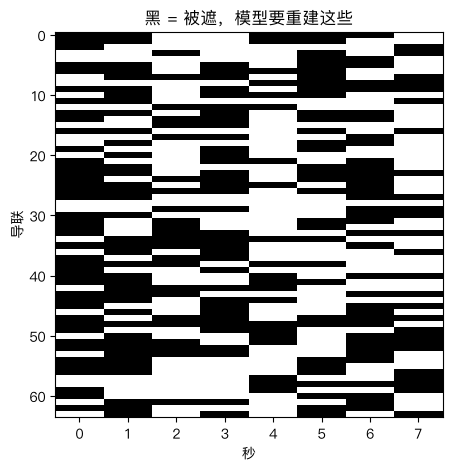

In [7]:
mask = random_mask(1, *win.shape[:2], cfg.mask_ratio, 'cpu')
print('mask', tuple(mask.shape), ' 遮了', mask.sum().item(), '/', mask.numel(), '个 token')
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(mask[0].numpy(), aspect='auto', cmap='gray_r'); ax.set(xlabel='秒', ylabel='导联', title='黑 = 被遮，模型要重建这些')
plt.show()

## 7. RoPE：打分只跟相对秒差有关

q 在 3 秒、k 在 5 秒 ： -1.4298
q 在 103 秒、k 在 105 秒： -1.4298   ← 相差都是 2 秒，打分相同
q 在 3 秒、k 在 6 秒 ： -1.5652   ← 相差 3 秒，打分变了


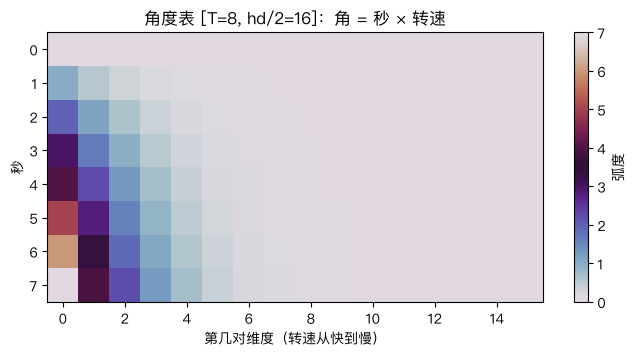

In [8]:
hd = cfg.d_model // cfg.n_heads
q = torch.randn(1, 1, 1, hd); k = torch.randn(1, 1, 1, hd)      # 同一对 q、k
def score(tq, tk):
    qr, _ = rope(q, q, torch.tensor([tq]))          # q 转到 tq 秒
    _, kr = rope(k, k, torch.tensor([tk]))          # k 转到 tk 秒
    return (qr * kr).sum().item()
print('q 在 3 秒、k 在 5 秒 ：', round(score(3, 5), 4))
print('q 在 103 秒、k 在 105 秒：', round(score(103, 105), 4), '  ← 相差都是 2 秒，打分相同')
print('q 在 3 秒、k 在 6 秒 ：', round(score(3, 6), 4), '  ← 相差 3 秒，打分变了')

inv = 1.0 / (10000 ** (torch.arange(0, hd, 2).float() / hd))
angs = torch.arange(cfg.T).float()[:, None] * inv[None]
fig, ax = plt.subplots(figsize=(8, 3.5))
im = ax.imshow(angs.numpy(), aspect='auto', cmap='twilight'); plt.colorbar(im, label='弧度')
ax.set(xlabel='第几对维度（转速从快到慢）', ylabel='秒', title=f'角度表 [T={cfg.T}, hd/2={hd//2}]：角 = 秒 × 转速')
plt.show()

## 8. 前缀掩码：时间头能看谁

In [9]:
for S in (-1, 0, 4):
    m = prefix_mask(cfg.T, S, 'cpu')
    print(f'S={S:>2} ({"全双向" if S<0 else "纯因果" if S==0 else "前缀 4 秒双向、之后因果"})')
    print('   全部可见' if m is None else '\n'.join('   ' + ''.join('■' if v else '·' for v in row) for row in m.tolist()))
print('行 = 查询秒，列 = 被看的秒，■ = 可见')

S=-1 (全双向)
   全部可见


S= 0 (纯因果)
   ■·······
   ■■······
   ■■■·····
   ■■■■····
   ■■■■■···
   ■■■■■■··
   ■■■■■■■·
   ■■■■■■■■
S= 4 (前缀 4 秒双向、之后因果)
   ■■■■····
   ■■■■····
   ■■■■····
   ■■■■····
   ■■■■■···
   ■■■■■■··
   ■■■■■■■·
   ■■■■■■■■
行 = 查询秒，列 = 被看的秒，■ = 可见


## 9. criss-cross 注意力：空间头看同秒跨导联，时间头看同导联跨秒

runs/base 还没训，用随机初始化演示形状
空间头打分矩阵 (64, 64) （同一秒、导联对导联）
时间头打分矩阵 (8, 8) （同一导联、秒对秒）


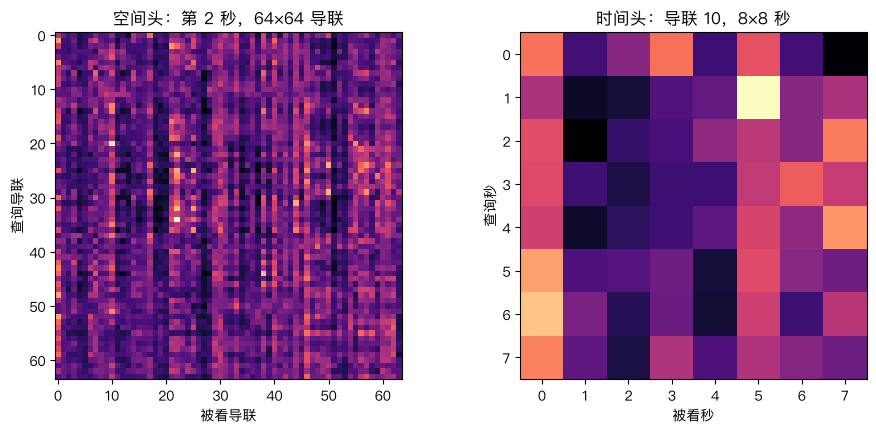

一个 Block 进出 (1, 64, 8, 128) → (1, 64, 8, 128)


In [10]:
model = EEGFM(cfg).eval()
import pathlib
ck = pathlib.Path(cfg.out_dir) / 'base' / 'ckpt.pt'
if ck.exists():
    model.load_state_dict(torch.load(ck, map_location='cpu')['model']); print('已加载预训练权重 runs/base')
else:
    print('runs/base 还没训，用随机初始化演示形状')

blk = model.blocks[0]; attn = blk.attn
xin = blk.ln1(h_in)
B, C, T, d = xin.shape
qkv = attn.qkv(xin).reshape(B, C, T, 3, attn.H, attn.hd)
q_, k_ = qkv[..., 0, :, :], qkv[..., 1, :, :]
hh = attn.H // 2
# 空间头 0，第 2 秒：C×C 打分
qs, ks = q_[0, :, 2, 0], k_[0, :, 2, 0]
A_space = torch.softmax(qs @ ks.T / math.sqrt(attn.hd), -1)
# 时间头（第 hh 个头），导联 10：T×T 打分，带 RoPE
qt, kt = q_[0, 10, :, hh][None, None], k_[0, 10, :, hh][None, None]
qt, kt = rope(qt, kt, torch.arange(T))
A_time = torch.softmax((qt[0, 0] @ kt[0, 0].T) / math.sqrt(attn.hd), -1)
print('空间头打分矩阵', tuple(A_space.shape), '（同一秒、导联对导联）')
print('时间头打分矩阵', tuple(A_time.shape), '（同一导联、秒对秒）')
fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))
axs[0].imshow(A_space.detach(), cmap='magma'); axs[0].set(title='空间头：第 2 秒，64×64 导联', xlabel='被看导联', ylabel='查询导联')
axs[1].imshow(A_time.detach(), cmap='magma'); axs[1].set(title='时间头：导联 10，8×8 秒', xlabel='被看秒', ylabel='查询秒')
plt.show()
out = blk(h_in); print('一个 Block 进出', tuple(h_in.shape), '→', tuple(out.shape))

## 10. 整模型：重建被遮 token

表征 (1, 64, 8, 128)  重建 (1, 64, 8, 160)  被遮 token 上 MSE = 1.6818 （输入方差≈1，随机模型≈1）


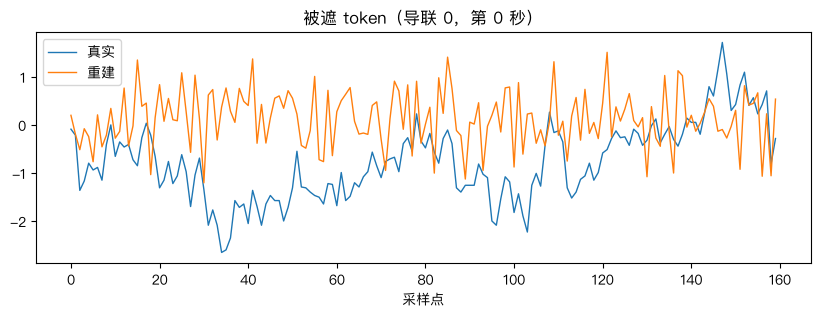

探针用的冻结特征：对 C、T 平均池化 → (1, 128)


In [11]:
xb = torch.from_numpy(win)[None]
with torch.no_grad():
    hrep = model.encode(xb, c, mask)
    pred = model.head(hrep)
    loss = F.mse_loss(pred[mask], xb[mask])
print('表征', tuple(hrep.shape), ' 重建', tuple(pred.shape), ' 被遮 token 上 MSE =', round(loss.item(), 4), '（输入方差≈1，随机模型≈1）')

ci, ti = mask[0].nonzero()[0].tolist()
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(xb[0, ci, ti], label='真实', lw=1); ax.plot(pred[0, ci, ti], label='重建', lw=1)
ax.set(title=f'被遮 token（导联 {ci}，第 {ti} 秒）', xlabel='采样点'); ax.legend(); plt.show()

feat_vec = model.features(xb, c)
print('探针用的冻结特征：对 C、T 平均池化 →', tuple(feat_vec.shape))